In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive



# Imports


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from typing import List


# Parameters


In [ ]:
# Time boundaries (microseconds)
START_DATE = dt.datetime(2025, 12, 1, 0, 0, 0).timestamp() * 1_000_000
END_DATE   = dt.datetime(2025, 12, 2, 0, 0, 0).timestamp() * 1_000_000

SYMBOLS = ['btcusdt', 'ethusdt']
BASE_PATH = '/content/drive/MyDrive/CMF_HFT/liquidation_task'


# Data Downloading


In [ ]:
def load_sym(sym):
    bin_trades = pl.scan_parquet(f'{BASE_PATH}/data/binance_trades/perp_{sym}.parquet') \
                   .filter(pl.col('timestamp').is_between(START_DATE, END_DATE))
    bin_bbo = pl.scan_parquet(f'{BASE_PATH}/data/binance_booktickers/perp_{sym}.parquet') \
                .filter(pl.col('timestamp').is_between(START_DATE, END_DATE))
    bin_liq = pl.scan_parquet(f'{BASE_PATH}/data/binance_liquidations/perp_{sym}.parquet') \
                .filter(pl.col('timestamp').is_between(START_DATE, END_DATE))
    byb_liq = pl.scan_parquet(f'{BASE_PATH}/data/bybit_liquidations/{sym}.parquet') \
                .filter(pl.col('timestamp').is_between(START_DATE, END_DATE))
    return {
        'bin_trades': bin_trades,
        'bin_bbo': bin_bbo,
        'bin_liq': bin_liq,
        'byb_liq': byb_liq
    }

data = {sym: load_sym(sym) for sym in SYMBOLS}

data['btcusdt']['bin_trades'].schema

# Quick preview
for sym in SYMBOLS:
    print(f'\n=== {sym} ===')
    for name, lf in data[sym].items():
        print(f'{name}: {lf.select(pl.len()).collect().item()} rows')



=== btcusdt ===
bin_trades: 6767867 rows
bin_bbo: 1322826 rows
bin_liq: 2922 rows
byb_liq: 7042 rows

=== ethusdt ===
bin_trades: 10475188 rows
bin_bbo: 1453969 rows
bin_liq: 2699 rows
byb_liq: 4696 rows


# Task 1.1 Foundational EDA


## Data Quality Check


### Missing values


In [ ]:

def check_missing(sym):
    for name, lf in data[sym].items():
        missing = lf.select(pl.all().is_null().sum()).select(pl.sum_horizontal(pl.all())).collect().item()
        print(f'{sym}_{name}: {"✅ no missing values" if missing == 0 else f"❌ {missing} missing values"}')

print('\n=== Missing values check ===')
for sym in SYMBOLS:
    check_missing(sym)



=== Missing values check ===
btcusdt_bin_trades: ✅ no missing values
btcusdt_bin_bbo: ✅ no missing values
btcusdt_bin_liq: ✅ no missing values
btcusdt_byb_liq: ✅ no missing values
ethusdt_bin_trades: ✅ no missing values
ethusdt_bin_bbo: ✅ no missing values
ethusdt_bin_liq: ✅ no missing values
ethusdt_byb_liq: ✅ no missing values


### Duplicates


In [ ]:
def check_duplicates(sym):
    for name, lf in data[sym].items():
        df = lf.collect()
        dup = df.height - df.unique().height
        print(f'{sym}_{name}: duplicates {dup} ({dup/df.height*100:.2f}%)')

print('\n=== Duplicates check ===')
for sym in SYMBOLS:
    check_duplicates(sym)



=== Duplicates check ===
btcusdt_bin_trades: duplicates 1216038 (17.97%)
btcusdt_bin_bbo: duplicates 0 (0.00%)
btcusdt_bin_liq: duplicates 0 (0.00%)
btcusdt_byb_liq: duplicates 0 (0.00%)
ethusdt_bin_trades: duplicates 1558156 (14.87%)
ethusdt_bin_bbo: duplicates 0 (0.00%)
ethusdt_bin_liq: duplicates 0 (0.00%)
ethusdt_byb_liq: duplicates 0 (0.00%)


### Timestamp consistency


In [ ]:
def check_monotonic(sym):
    for name, lf in data[sym].items():
        df = lf.collect()
        if df['timestamp'].is_sorted():
            print(f'{sym}_{name}: ✅ timestamp is monotonic')
        else:
            print(f'{sym}_{name}: ❌ timestamp is NOT monotonic – sorting')
            data[sym][name] = df.sort('timestamp').lazy()

print('\n=== Timestamp monotonicity check ===')
for sym in SYMBOLS:
    check_monotonic(sym)



=== Timestamp monotonicity check ===
btcusdt_bin_trades: ✅ timestamp is monotonic
btcusdt_bin_bbo: ✅ timestamp is monotonic
btcusdt_bin_liq: ✅ timestamp is monotonic
btcusdt_byb_liq: ❌ timestamp is NOT monotonic – sorting
ethusdt_bin_trades: ✅ timestamp is monotonic
ethusdt_bin_bbo: ✅ timestamp is monotonic
ethusdt_bin_liq: ✅ timestamp is monotonic
ethusdt_byb_liq: ❌ timestamp is NOT monotonic – sorting


### Data frequency


In [ ]:
def events_freq(sym):
    for name, lf in data[sym].items():
        dur = (lf.select(pl.col('timestamp').max()).collect().item() -
               lf.select(pl.col('timestamp').min()).collect().item()) / 1_000_000  # seconds
        cnt = lf.select(pl.len()).collect().item()
        freq = cnt / dur if dur > 0 else 0
        print(f'{sym}_{name}: {freq:.2f} events/sec')

print('\n=== Event frequency ===')
for sym in SYMBOLS:
    events_freq(sym)



=== Event frequency ===
btcusdt_bin_trades: 78.33 events/sec
btcusdt_bin_bbo: 15.31 events/sec
btcusdt_bin_liq: 0.03 events/sec
btcusdt_byb_liq: 0.08 events/sec
ethusdt_bin_trades: 121.24 events/sec
ethusdt_bin_bbo: 16.83 events/sec
ethusdt_bin_liq: 0.03 events/sec
ethusdt_byb_liq: 0.05 events/sec


- Overall, the data is quite clean.

- The existence of duplicates is likely explained by the fact that one large market order is executed simultaneously against several limit orders at the same price within the same microsecond. Exchanges record each such partial fill as a separate row, hence many entries with identical time, price, and side — these are not duplicates of a single event but actual different trades.

- Liquidations occur much less frequently (about two orders of magnitude less) than trades and LOB updates.


## Univariate Analysis


### Price & Amount distributions




=== Distributions ===


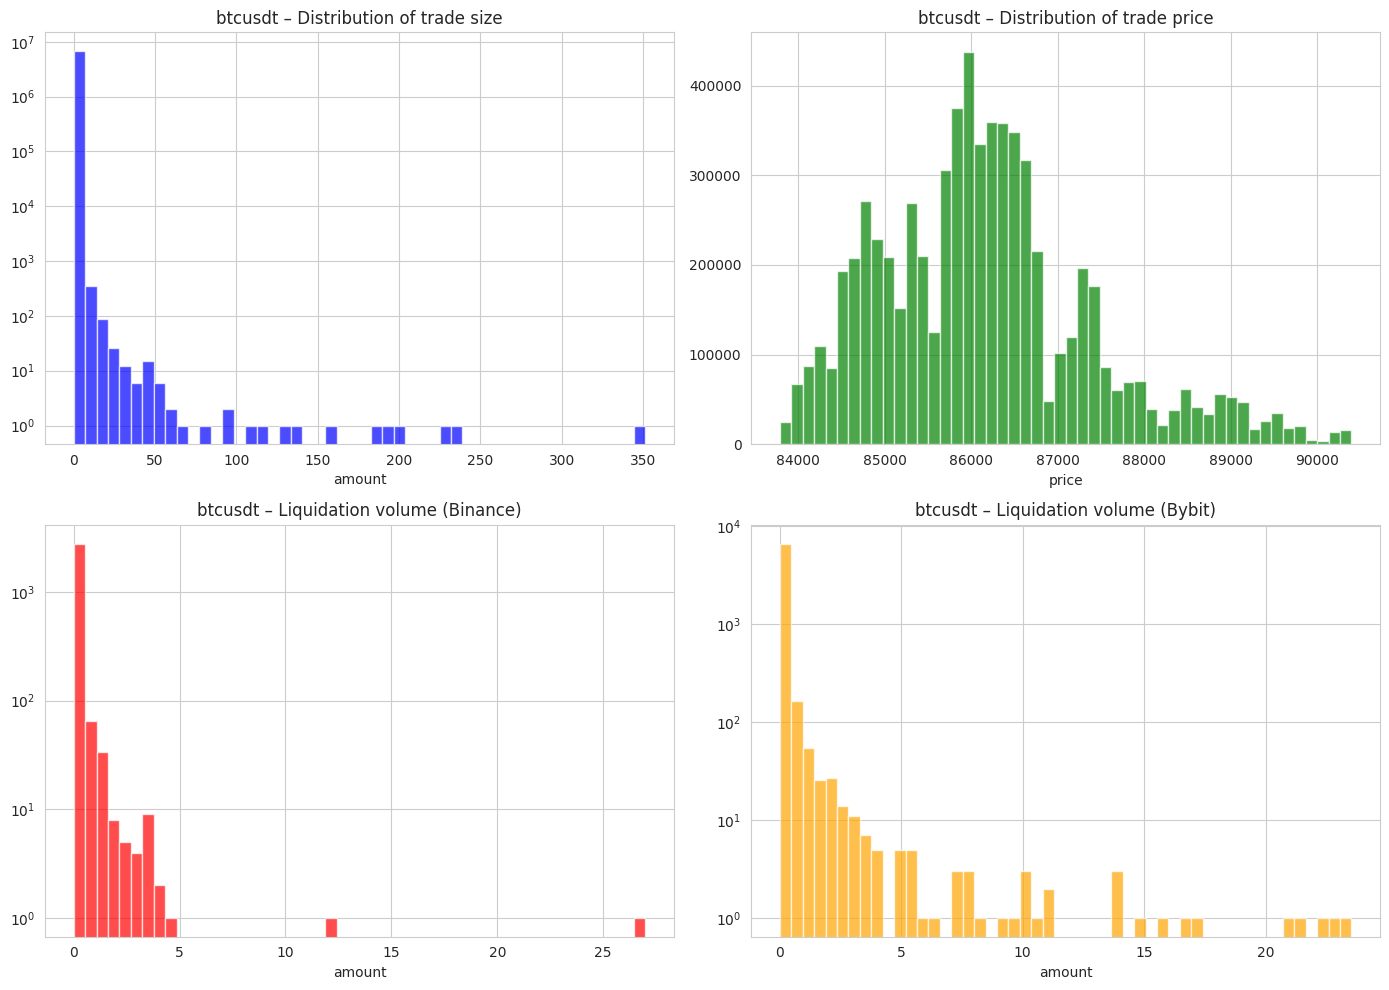

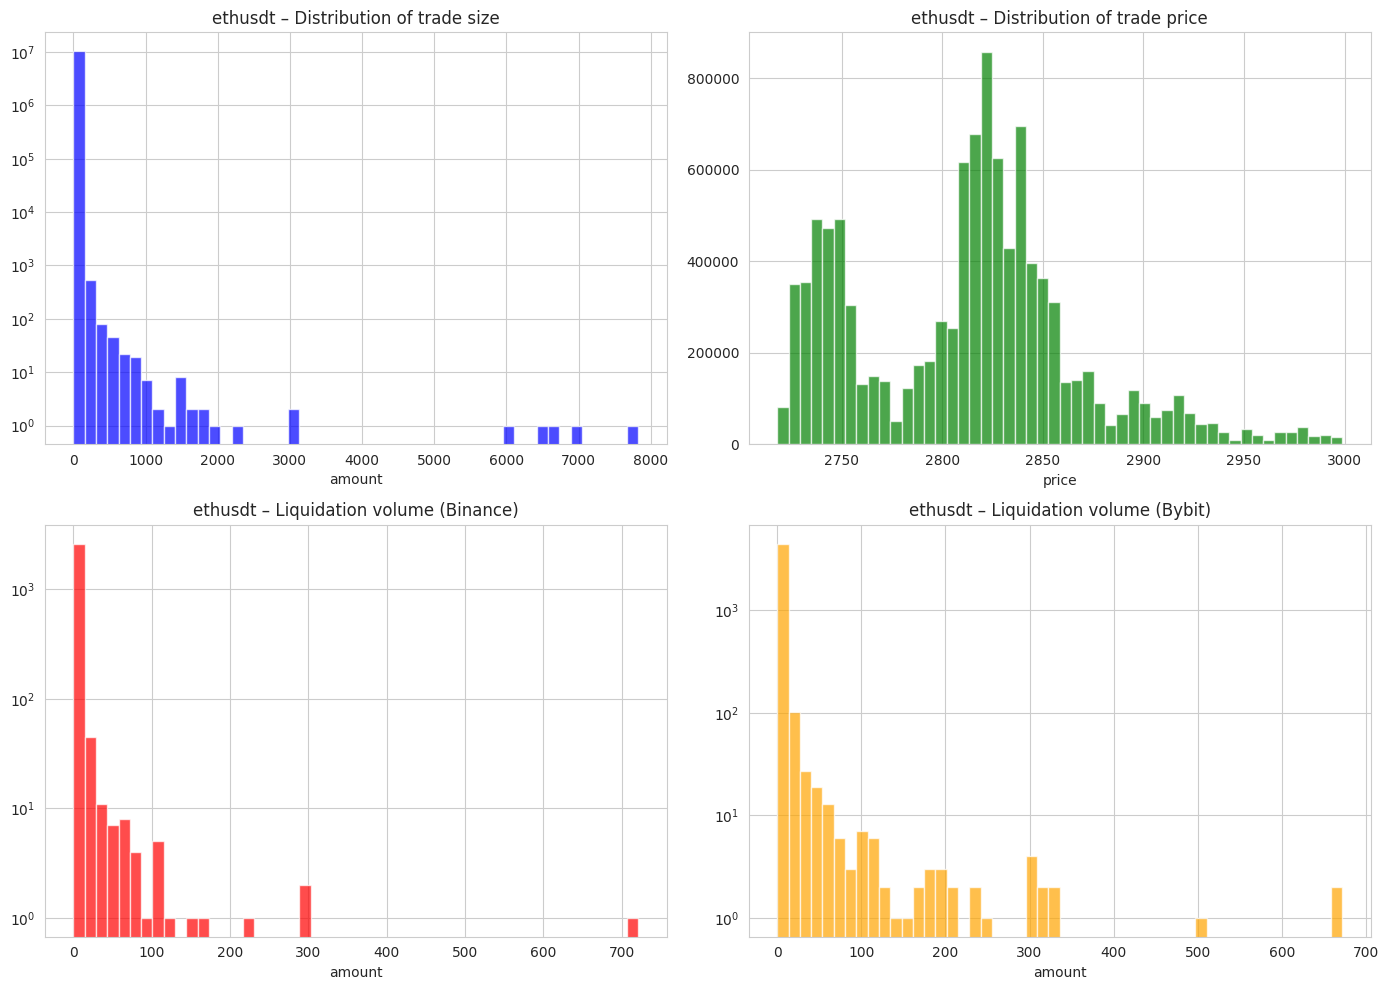

In [ ]:
def plot_distributions(sym):
    # Trade sizes
    trade_amt = data[sym]['bin_trades'].select(pl.col('amount')).collect().to_numpy().flatten()
    # Trade prices
    trade_price = data[sym]['bin_trades'].select(pl.col('price')).collect().to_numpy().flatten()
    # Liquidation volumes (Binance)
    liq_amt_bin = data[sym]['bin_liq'].select(pl.col('amount')).collect().to_numpy().flatten()
    # Liquidation volumes (Bybit)
    liq_amt_byb = data[sym]['byb_liq'].select(pl.col('amount')).collect().to_numpy().flatten()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0,0].hist(trade_amt, bins=50, alpha=0.7, color='blue')
    axes[0,0].set_title(f'{sym} – Distribution of trade size')
    axes[0,0].set_xlabel('amount')
    axes[0,0].set_yscale('log')

    axes[0,1].hist(trade_price, bins=50, alpha=0.7, color='green')
    axes[0,1].set_title(f'{sym} – Distribution of trade price')
    axes[0,1].set_xlabel('price')

    axes[1,0].hist(liq_amt_bin, bins=50, alpha=0.7, color='red')
    axes[1,0].set_title(f'{sym} – Liquidation volume (Binance)')
    axes[1,0].set_xlabel('amount')
    axes[1,0].set_yscale('log')

    axes[1,1].hist(liq_amt_byb, bins=50, alpha=0.7, color='orange')
    axes[1,1].set_title(f'{sym} – Liquidation volume (Bybit)')
    axes[1,1].set_xlabel('amount')
    axes[1,1].set_yscale('log')

    plt.tight_layout()
    plt.show()

print('\n=== Distributions ===')
for sym in SYMBOLS:
    plot_distributions(sym)


- The distribution of trade sizes has a long tail. In reality, large market orders probably arrive more often, but since limit orders usually have small sizes, a large market order is split into several small and large orders on the distribution plot, making it slightly skewed.

- Liquidation volumes are on average much smaller than regular trade volumes.

- Bybit liquidation volumes have a thicker tail than Binance liquidation volumes.


### Price vs Time



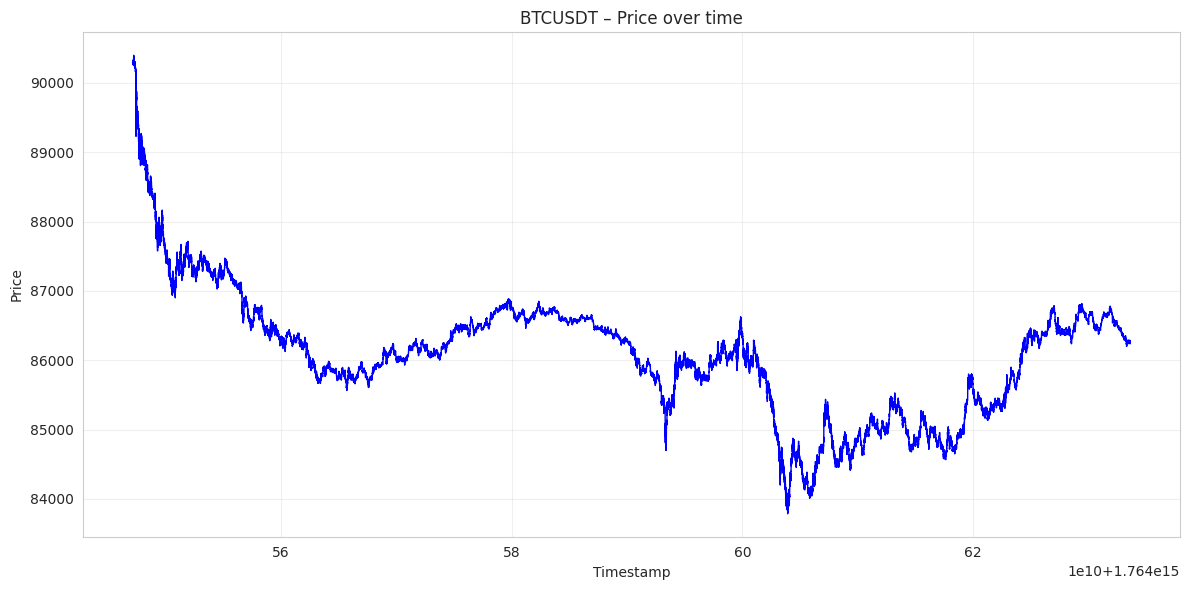

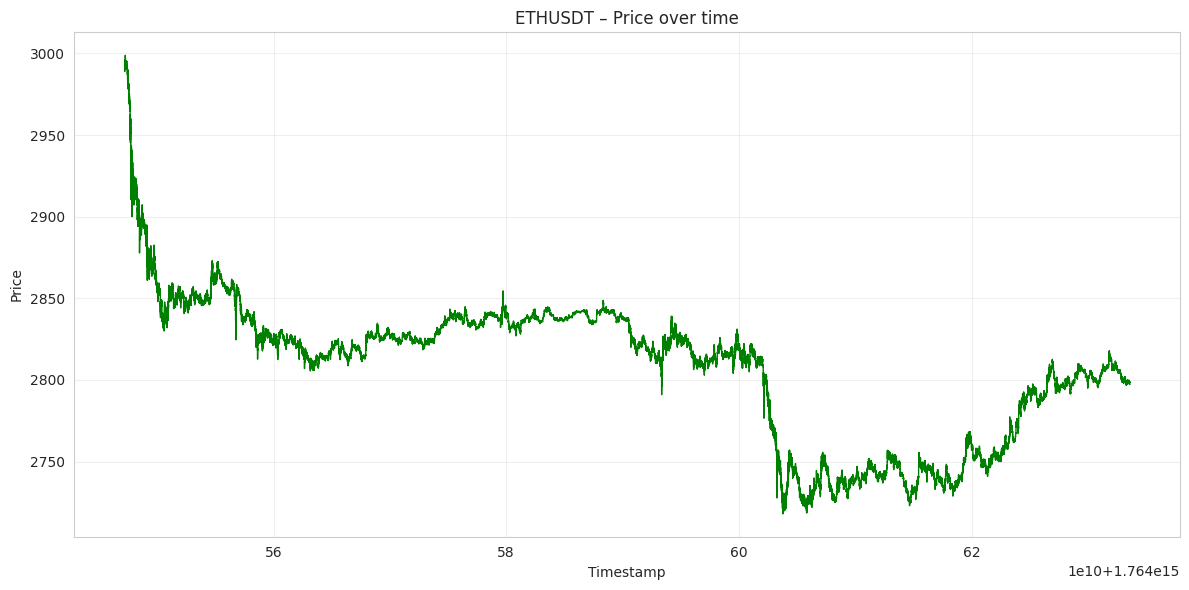

In [ ]:
def plot_price_time(sym: str) -> None:
    """
    Plots price over time for symbol sym.
    """
    if sym not in data:
        raise ValueError(f"Symbol {sym} not found in data")

    # Take only timestamp and price, sort by time
    df = (
        data[sym]['bin_trades']
        .select(['timestamp', 'price'])
        .sort('timestamp')
        .collect()
    )

    # If timestamp is in milliseconds, you can convert to datetime for readable x-axis
    # For example, if timestamp is in ms:
    # df = df.with_columns(pl.col('timestamp').cast(pl.Datetime(time_unit='ms')))
    # But for simplicity, keep as is, or uncomment if needed

    plt.figure(figsize=(12, 6))
    plt.plot(df['timestamp'], df['price'], linewidth=1, color='blue' if sym=='btcusdt' else 'green')
    plt.title(f'{sym.upper()} – Price over time')
    plt.xlabel('Timestamp')
    plt.ylabel('Price')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call for each symbol in SYMBOLS
for sym in SYMBOLS:
    plot_price_time(sym)


### Hourly patterns



=== Intraday patterns ===


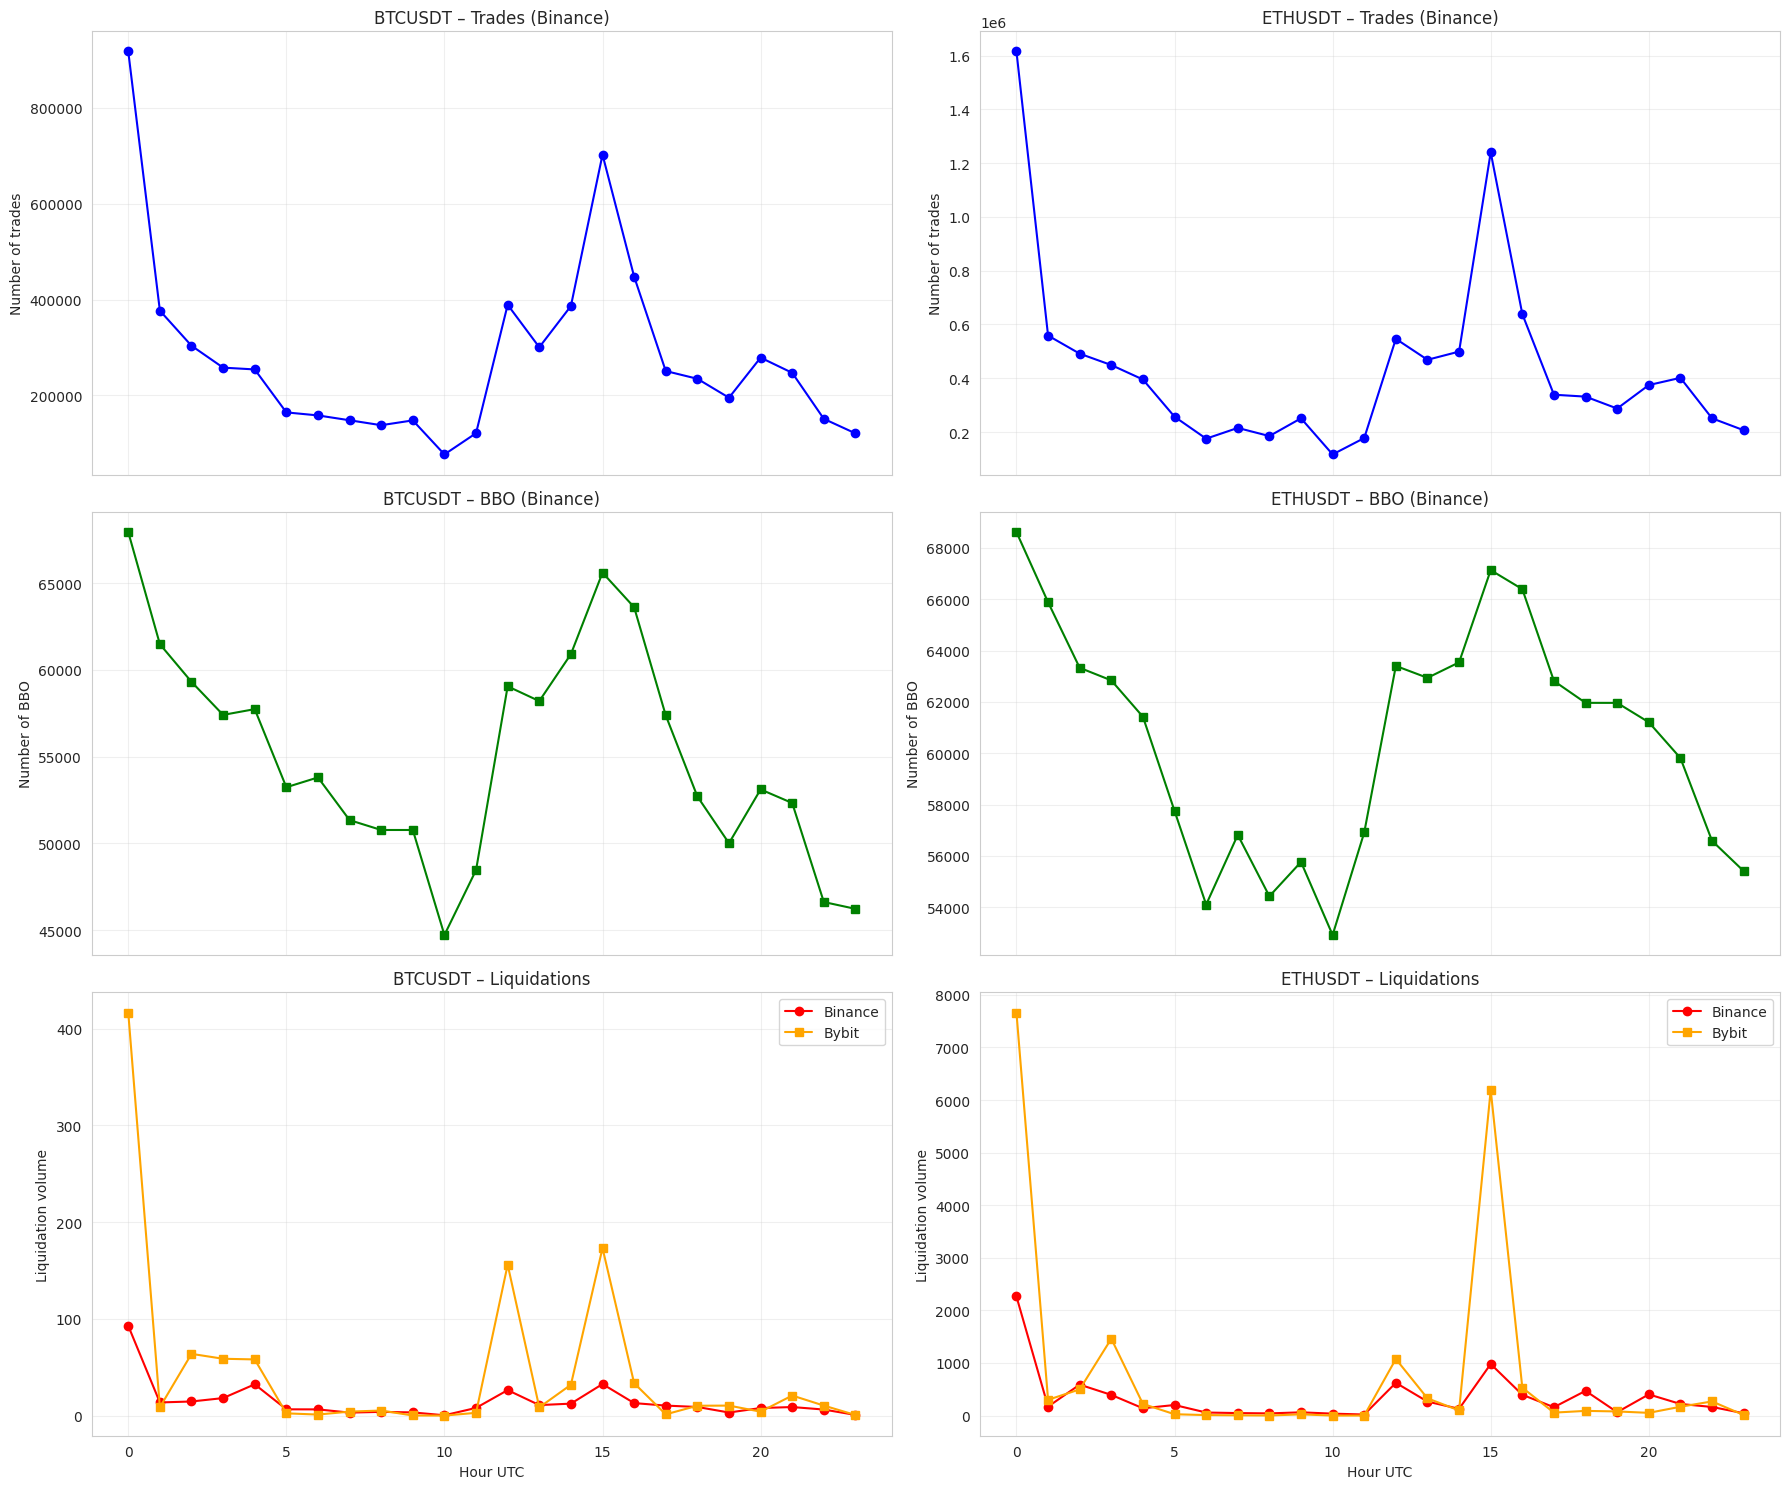

In [ ]:
def plot_hourly_patterns_all(symbols):
    hours_range = pl.DataFrame({'hour': range(24)})
    fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=True)
    row_titles = ['Trades (Binance)', 'BBO (Binance)', 'Liquidations']

    for col_idx, sym in enumerate(symbols):
        # ---- Trades ----
        trades = data[sym]['bin_trades']
        trades_hour = (
            trades
            .with_columns(pl.col('timestamp').cast(pl.Datetime(time_unit='us')).dt.hour().alias('hour'))
            .group_by('hour')
            .agg(pl.len().alias('count'))
            .collect()
            .sort('hour')
        )
        trades_hour = hours_range.join(trades_hour, on='hour', how='left').fill_null(0)
        ax = axes[0, col_idx]
        ax.plot(trades_hour['hour'], trades_hour['count'], marker='o', linestyle='-', color='blue')
        ax.set_title(f'{sym.upper()} – {row_titles[0]}')
        ax.set_ylabel('Number of trades')
        ax.grid(True, alpha=0.3)

        # ---- BBO ----
        bbo = data[sym]['bin_bbo']
        bbo_hour = (
            bbo
            .with_columns(pl.col('timestamp').cast(pl.Datetime(time_unit='us')).dt.hour().alias('hour'))
            .group_by('hour')
            .agg(pl.len().alias('count'))
            .collect()
            .sort('hour')
        )
        bbo_hour = hours_range.join(bbo_hour, on='hour', how='left').fill_null(0)
        ax = axes[1, col_idx]
        ax.plot(bbo_hour['hour'], bbo_hour['count'], marker='s', linestyle='-', color='green')
        ax.set_title(f'{sym.upper()} – {row_titles[1]}')
        ax.set_ylabel('Number of BBO')
        ax.grid(True, alpha=0.3)

        # ---- Liquidations (Binance + Bybit) ----
        bin_liq = data[sym]['bin_liq']
        bin_liq_hour = (
            bin_liq
            .with_columns(pl.col('timestamp').cast(pl.Datetime(time_unit='us')).dt.hour().alias('hour'))
            .group_by('hour')
            .agg(pl.sum('amount').alias('vol'))
            .collect()
            .sort('hour')
        )
        bin_liq_hour = hours_range.join(bin_liq_hour, on='hour', how='left').fill_null(0)

        byb_liq = data[sym]['byb_liq']
        byb_liq_hour = (
            byb_liq
            .with_columns(pl.col('timestamp').cast(pl.Datetime(time_unit='us')).dt.hour().alias('hour'))
            .group_by('hour')
            .agg(pl.sum('amount').alias('vol'))
            .collect()
            .sort('hour')
        )
        byb_liq_hour = hours_range.join(byb_liq_hour, on='hour', how='left').fill_null(0)

        ax = axes[2, col_idx]
        ax.plot(bin_liq_hour['hour'], bin_liq_hour['vol'], marker='o', linestyle='-', label='Binance', color='red')
        ax.plot(byb_liq_hour['hour'], byb_liq_hour['vol'], marker='s', linestyle='-', label='Bybit', color='orange')
        ax.set_title(f'{sym.upper()} – {row_titles[2]}')
        ax.set_ylabel('Liquidation volume')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Common x-axis label for the bottom row
    for ax in axes[-1, :]:
        ax.set_xlabel('Hour UTC')

    plt.tight_layout()
    plt.show()


print('\n=== Intraday patterns ===')
plot_hourly_patterns_all(SYMBOLS)


- Peaks on the charts correspond to the start of the Asian session and overlaps of European and American sessions.

- Time of day can be used as a feature: if a large number of trades or liquidations occur at a time when such activity is not usual, it may indicate something "unusual".



## Basic Cross-Exchange Comparison


### Amount comparison



In [ ]:
def compare_exchanges(sym):
    bin_cnt = data[sym]['bin_liq'].select(pl.len()).collect().item()
    byb_cnt = data[sym]['byb_liq'].select(pl.len()).collect().item()
    bin_vol = data[sym]['bin_liq'].select(pl.sum('amount')).collect().item()
    byb_vol = data[sym]['byb_liq'].select(pl.sum('amount')).collect().item()
    print(f'{sym}:')
    print(f'  Binance – events: {bin_cnt}, volume: {bin_vol:.2f}')
    print(f'  Bybit   – events: {byb_cnt}, volume: {byb_vol:.2f}')
    if bin_cnt > byb_cnt:
        print('  Binance shows higher liquidation frequency.')
    else:
        print('  Bybit shows higher liquidation frequency.')

print('\n=== Exchange comparison ===')
for sym in SYMBOLS:
    compare_exchanges(sym)
    print()



=== Exchange comparison ===
btcusdt:
  Binance – events: 2922, volume: 343.72
  Bybit   – events: 7042, volume: 1081.87
  Bybit shows higher liquidation frequency.

ethusdt:
  Binance – events: 2699, volume: 7942.36
  Bybit   – events: 4696, volume: 19153.01
  Bybit shows higher liquidation frequency.



# Task 1.2 Intermediate Analysis



## Broad market EDA


### Spread distributions




=== Spread analysis ===


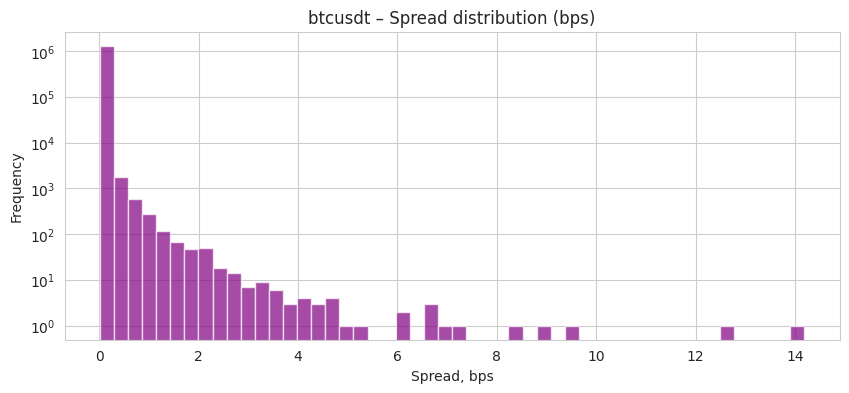

btcusdt – average spread: 0.014 bps, median: 0.012 bps, 95th percentile: 0.012 bps


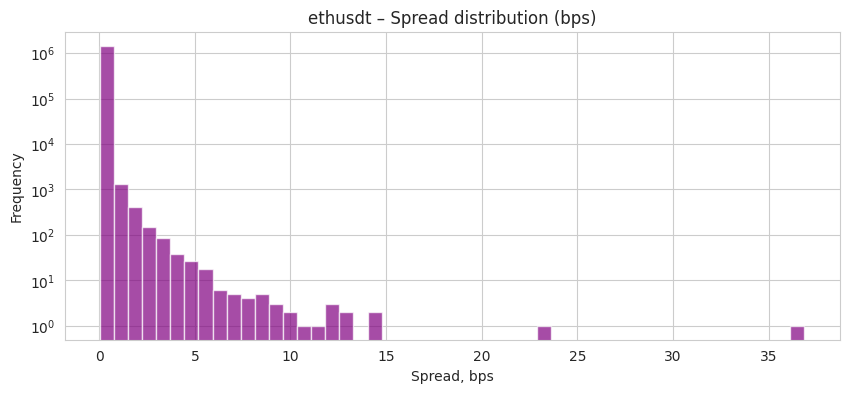

ethusdt – average spread: 0.040 bps, median: 0.035 bps, 95th percentile: 0.037 bps


In [ ]:
def spread_analysis(sym):
    bbo = data[sym]['bin_bbo']
    # Compute spread in basis points (bps)
    spread_df = bbo.with_columns(
        ((pl.col('ask_price') - pl.col('bid_price')) / pl.col('bid_price') * 10000).alias('spread_bps')
    ).select('spread_bps').collect()
    spread = spread_df['spread_bps'].to_numpy()

    plt.figure(figsize=(10,4))
    plt.hist(spread, bins=50, alpha=0.7, color='purple')
    plt.title(f'{sym} – Spread distribution (bps)')
    plt.xlabel('Spread, bps')
    plt.ylabel('Frequency')
    plt.yscale('log')
    plt.show()

    print(f'{sym} – average spread: {np.mean(spread):.3f} bps, median: {np.median(spread):.3f} bps, 95th percentile: {np.percentile(spread,95):.3f} bps')

print('\n=== Spread analysis ===')
for sym in SYMBOLS:
    spread_analysis(sym)


- As expected for liquid assets, the spread is mostly narrow.
- If at some point the spread widens beyond certain limits, this could be used as a feature.


### Trade stats


In [ ]:
def trade_stats(sym):
    trades = data[sym]['bin_trades']
    # Statistics on volume
    amt = trades.select('amount').collect().to_numpy().flatten()
    # Share of taker buy / sell
    side_counts = trades.group_by('side').agg(pl.len()).collect()
    total = side_counts['len'].sum()
    buy_pct = side_counts.filter(pl.col('side') == 'buy')['len'].item() / total * 100 if 'buy' in side_counts['side'] else 0
    sell_pct = 100 - buy_pct
    print(f'{sym}:')
    print(f'  Average trade size: {np.mean(amt):.4f}')
    print(f'  Median size: {np.median(amt):.4f}')
    print(f'  Buy share: {buy_pct:.1f}%, sell: {sell_pct:.1f}%')

    # Trade frequency per second
    trades_sec = trades.with_columns(
        (pl.col('timestamp') // 1_000_000).alias('sec')  # whole seconds
    ).group_by('sec').agg(pl.len().alias('cnt')).collect()
    avg_freq = trades_sec['cnt'].mean()
    print(f'  Average number of trades per second: {avg_freq:.2f}')

print('\n=== Trade statistics ===')
for sym in SYMBOLS:
    trade_stats(sym)
    print()



=== Trade statistics ===
btcusdt:
  Average trade size: 0.0439
  Median size: 0.0030
  Buy share: 50.1%, sell: 49.9%
  Average number of trades per second: 78.85

ethusdt:
  Average trade size: 0.6434
  Median size: 0.0250
  Buy share: 49.8%, sell: 50.2%
  Average number of trades per second: 121.66



- As expected for liquid assets, the buy/sell ratio is nearly equal.

- If over some period the buy share outweighs sell (or vice versa), this could be used as a feature.



## ML EDA


### Markout calculation



In [ ]:
def add_mid(bbo_lf: pl.LazyFrame) -> pl.LazyFrame:
    return bbo_lf.with_columns(
        ((pl.col('bid_price') + pl.col('ask_price')) / 2).alias('mid')
    )

def add_notional(trades_lf: pl.LazyFrame) -> pl.LazyFrame:
    return trades_lf.with_columns(
        (pl.col('price') * pl.col('amount')).alias('notional')
    )

def compute_markout(
    trades_lf: pl.LazyFrame,
    bbo_lf: pl.LazyFrame,
    horizon_s: List[int] = [30, 120, 300],
) -> pl.LazyFrame:
    """
    Computes maker PnL (in bps) for each trade at multiple horizons.
    Formula: pnl = -sign * (mid(t+h) - price) / price * 10000 + 0.5
    sign = +1 for taker-buy (maker-sell), -1 for taker-sell (maker-buy).
    For each horizon h, a column pnl_{h} is added.
    If BBO at time t+h is missing, pnl_{h} = null.
    """
    # Prepare BBO
    bbo_mid = add_mid(bbo_lf).select('timestamp', 'mid').sort('timestamp')

    # Base LazyFrame with trades
    df = (
        trades_lf
        .pipe(add_notional)
        .sort('timestamp')
        .with_columns(
            sign=pl.when(pl.col('side') == 'buy')
                   .then(pl.lit(1))
                   .otherwise(pl.lit(-1))
        )
    )

    # For each horizon, do a separate asof join and save mid to a separate column
    for h in horizon_s:
        horizon_us = h * 1_000_000
        ts_future_col = f'ts_future_{h}'
        mid_col = f'mid_{h}'
        df = df.with_columns(
            (pl.col('timestamp') + horizon_us).alias(ts_future_col)
        )
        df = df.join_asof(
            bbo_mid,
            left_on=ts_future_col,
            right_on='timestamp',
            strategy='backward'
        )
        df = df.rename({'mid': mid_col})
        df = df.drop('timestamp_right')

    # Compute pnl for each horizon
    for h in horizon_s:
        mid_col = f'mid_{h}'
        pnl_col = f'pnl_{h}'
        df = df.with_columns(
            (
                -1
                * pl.col('sign')
                * (pl.col(mid_col) - pl.col('price'))
                / pl.col('price')
                * 10_000
                + 0.5
            ).alias(pnl_col)
        )

    # Add weight (common for all horizons)
    df = df.with_columns(
        weight=pl.col('notional').clip(upper_bound=100_000)
    )

    return df


In [ ]:

def print_markout_summary(sym: str) -> None:
    """
    Computes and prints sums and average PnL for three horizons (30, 120, 300 seconds).
    """
    if sym not in data:
        raise ValueError(f"Symbol {sym} not found in data")
    trades = data[sym]['bin_trades']
    bbo = data[sym]['bin_bbo']

    lazy_result = compute_markout(trades, bbo)
    stats = (
        lazy_result
        .select([
            pl.col('pnl_30').sum().alias('sum_30'),
            pl.col('pnl_30').count().alias('count_30'),
            pl.col('pnl_120').sum().alias('sum_120'),
            pl.col('pnl_120').count().alias('count_120'),
            pl.col('pnl_300').sum().alias('sum_300'),
            pl.col('pnl_300').count().alias('count_300'),
        ])
        .collect()
    )

    print(f"PnL_all_{sym} 30s: {stats[0, 'sum_30']:.2f} bps")
    print(f"PnL_all_{sym} 120s: {stats[0, 'sum_120']:.2f} bps")
    print(f"PnL_all_{sym} 300s: {stats[0, 'sum_300']:.2f} bps")
    print(f"Avg PnL_{sym} 30s: {stats[0, 'sum_30'] / stats[0, 'count_30']:.2f} bps (n={stats[0, 'count_30']})")
    print(f"Avg PnL_{sym} 120s: {stats[0, 'sum_120'] / stats[0, 'count_120']:.2f} bps (n={stats[0, 'count_120']})")
    print(f"Avg PnL_{sym} 300s: {stats[0, 'sum_300'] / stats[0, 'count_300']:.2f} bps (n={stats[0, 'count_300']})")
    print()


for sym in SYMBOLS:
    print_markout_summary(sym)


PnL_all_btcusdt 30s: -1421749.31 bps
PnL_all_btcusdt 120s: -2083707.90 bps
PnL_all_btcusdt 300s: -2836583.61 bps
Avg PnL_btcusdt 30s: -0.21 bps (n=6767867)
Avg PnL_btcusdt 120s: -0.31 bps (n=6767867)
Avg PnL_btcusdt 300s: -0.42 bps (n=6767867)

PnL_all_ethusdt 30s: 970515.01 bps
PnL_all_ethusdt 120s: 2038529.09 bps
PnL_all_ethusdt 300s: 42334.06 bps
Avg PnL_ethusdt 30s: 0.09 bps (n=10475188)
Avg PnL_ethusdt 120s: 0.19 bps (n=10475188)
Avg PnL_ethusdt 300s: 0.00 bps (n=10475188)



### Markout vs time"""


In [ ]:
trades = data[sym]['bin_trades']
bbo = data[sym]['bin_bbo']
lazy_result = compute_markout(trades, bbo)

lazy_result.fetch(5)


timestamp,ticker,side,price,amount,notional,sign,ts_future_30,mid_30,ts_future_120,mid_120,ts_future_300,mid_300,pnl_30,pnl_120,pnl_300,weight
i64,str,str,f64,f64,f64,i32,i64,f64,i64,f64,i64,f64,f64,f64,f64,f64
1764547200016000,"""perp:ethusdt""","""buy""",2990.02,0.2,598.004,1,1764547230016000,2993.295,1764547320016000,2991.655,1764547500016000,2985.845,-10.453104,-4.968191,14.463117,598.004
1764547200025000,"""perp:ethusdt""","""sell""",2990.01,0.053,158.47053,-1,1764547230025000,2993.295,1764547320025000,2991.655,1764547500025000,2985.845,11.486585,6.001654,-13.429719,158.47053
1764547200036000,"""perp:ethusdt""","""sell""",2990.01,2.151,6431.51151,-1,1764547230036000,2993.295,1764547320036000,2991.655,1764547500036000,2985.845,11.486585,6.001654,-13.429719,6431.51151
1764547200038000,"""perp:ethusdt""","""sell""",2990.01,1.785,5337.16785,-1,1764547230038000,2993.295,1764547320038000,2991.655,1764547500038000,2985.845,11.486585,6.001654,-13.429719,5337.16785
1764547200038000,"""perp:ethusdt""","""sell""",2990.01,1.911,5713.90911,-1,1764547230038000,2993.295,1764547320038000,2991.655,1764547500038000,2985.845,11.486585,6.001654,-13.429719,5713.90911


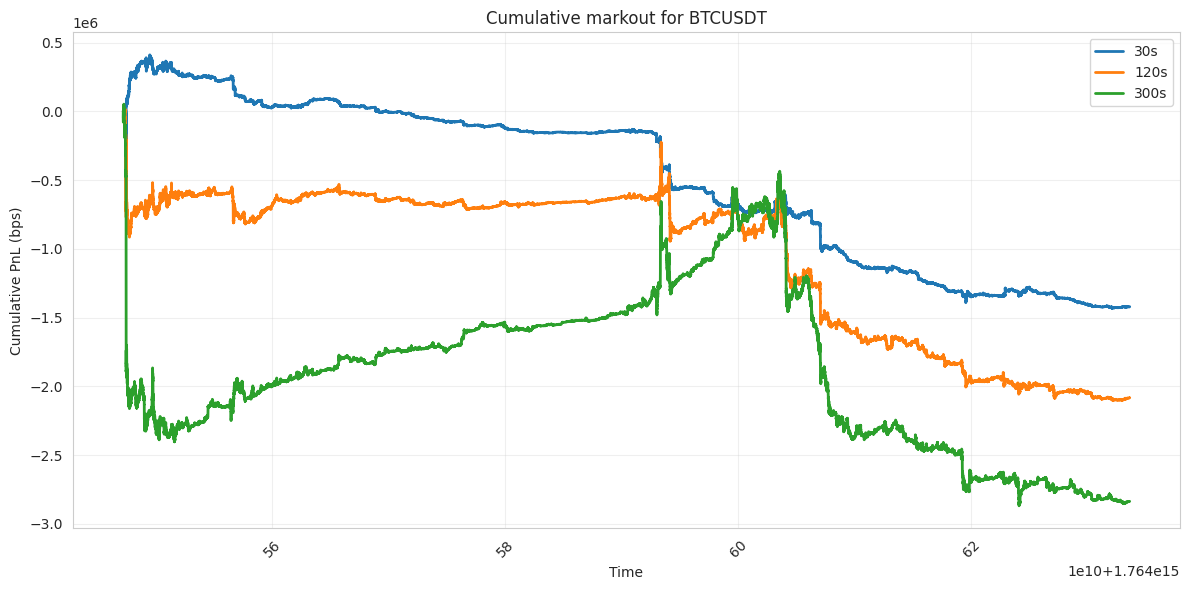

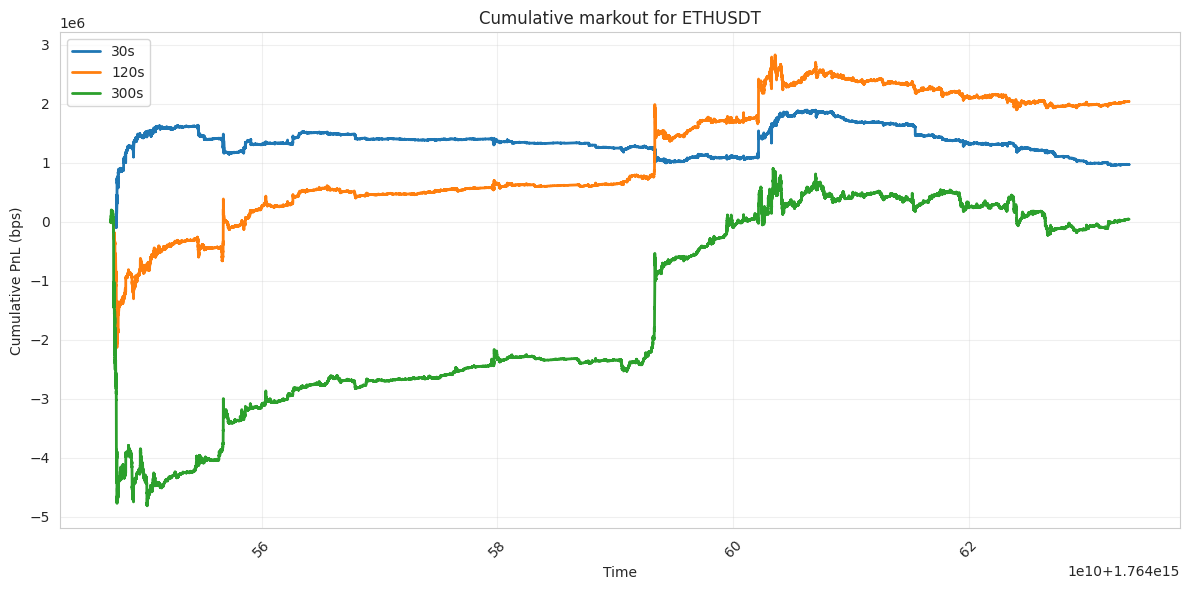

In [ ]:
def plot_cumulative_markout(sym: str) -> None:
    """
    Plots cumulative markout (sum of pnl per trade)
    for three horizons (30, 120, 300 seconds) for a given instrument.
    """
    if sym not in data:
        raise ValueError(f"Symbol {sym} not found in data")

    trades = data[sym]['bin_trades']
    bbo = data[sym]['bin_bbo']

    lazy_result = compute_markout(trades, bbo)  # contains columns timestamp, pnl_30, pnl_120, pnl_300

    # Extract only required columns, sort by time, collect
    df = (
        lazy_result
        .select(['timestamp', 'pnl_30', 'pnl_120', 'pnl_300'])
        .sort('timestamp')
        .collect()
    )

    # Compute cumulative sums for each horizon
    df = df.with_columns([
        pl.col('pnl_30').cum_sum().alias('cum_pnl_30'),
        pl.col('pnl_120').cum_sum().alias('cum_pnl_120'),
        pl.col('pnl_300').cum_sum().alias('cum_pnl_300'),
    ])

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df['timestamp'], df['cum_pnl_30'], label='30s', linewidth=2)
    plt.plot(df['timestamp'], df['cum_pnl_120'], label='120s', linewidth=2)
    plt.plot(df['timestamp'], df['cum_pnl_300'], label='300s', linewidth=2)

    plt.xlabel('Time')
    plt.ylabel('Cumulative PnL (bps)')
    plt.title(f'Cumulative markout for {sym.upper()}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_cumulative_markout('btcusdt')
plot_cumulative_markout('ethusdt')


### Markout vs amount


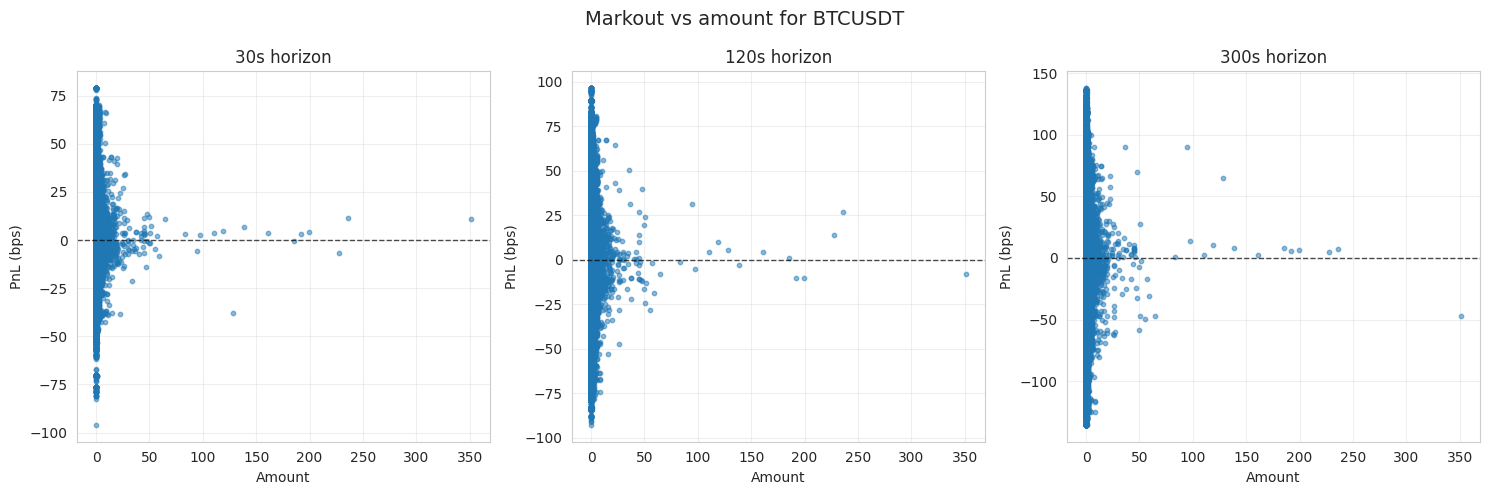

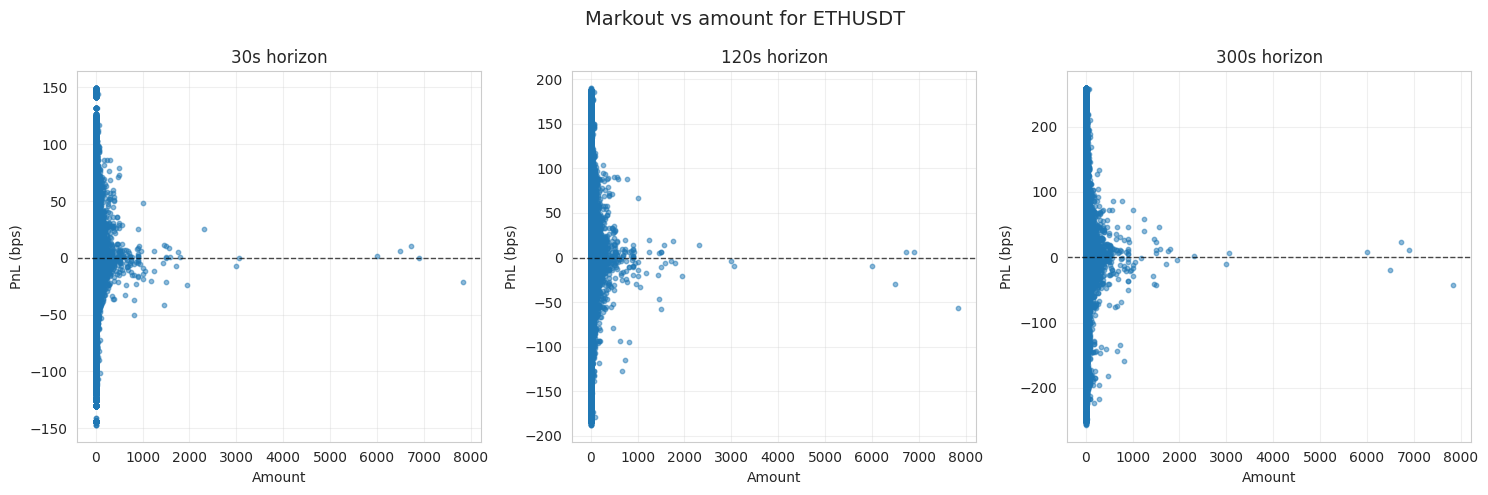

In [ ]:
def plot_markout_vs_amount(sym: str) -> None:
    """
    Plots scatter: markout (bps) vs amount for three horizons.
    """
    if sym not in data:
        raise ValueError(f"Symbol {sym} not found in data")

    trades = data[sym]['bin_trades']
    bbo = data[sym]['bin_bbo']

    lazy_result = compute_markout(trades, bbo)  # contains columns amount, pnl_30, pnl_120, pnl_300

    # Collect only needed columns
    df = (
        lazy_result
        .select(['amount', 'pnl_30', 'pnl_120', 'pnl_300'])
        .collect()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    horizons = [
        ('pnl_30', '30s'),
        ('pnl_120', '120s'),
        ('pnl_300', '300s')
    ]

    for ax, (pnl_col, label) in zip(axes, horizons):
        # Remove rows with missing pnl for this horizon
        sub = df.drop_nulls(subset=[pnl_col])
        ax.scatter(sub['amount'], sub[pnl_col], alpha=0.5, s=10)
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_xlabel('Amount')
        ax.set_ylabel('PnL (bps)')
        ax.set_title(f'{label} horizon')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Markout vs amount for {sym.upper()}', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_markout_vs_amount('btcusdt')
plot_markout_vs_amount('ethusdt')


- Visually, for BTCUSDT, trades with large volume seem to yield positive pnl. Further verification is needed.


### Markout distribution



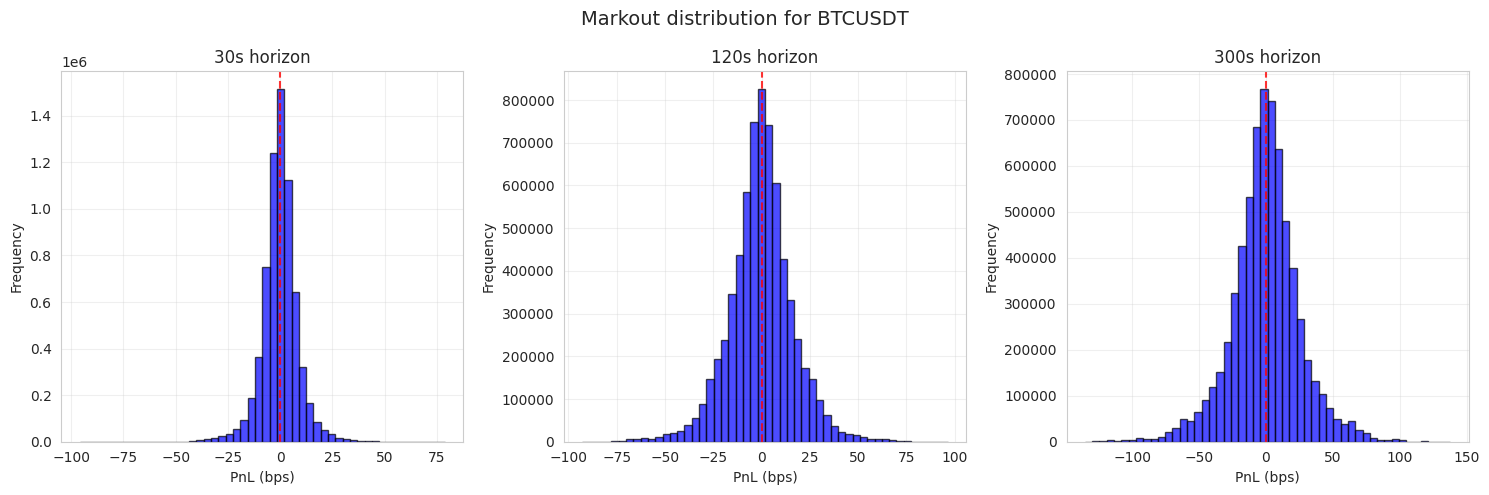

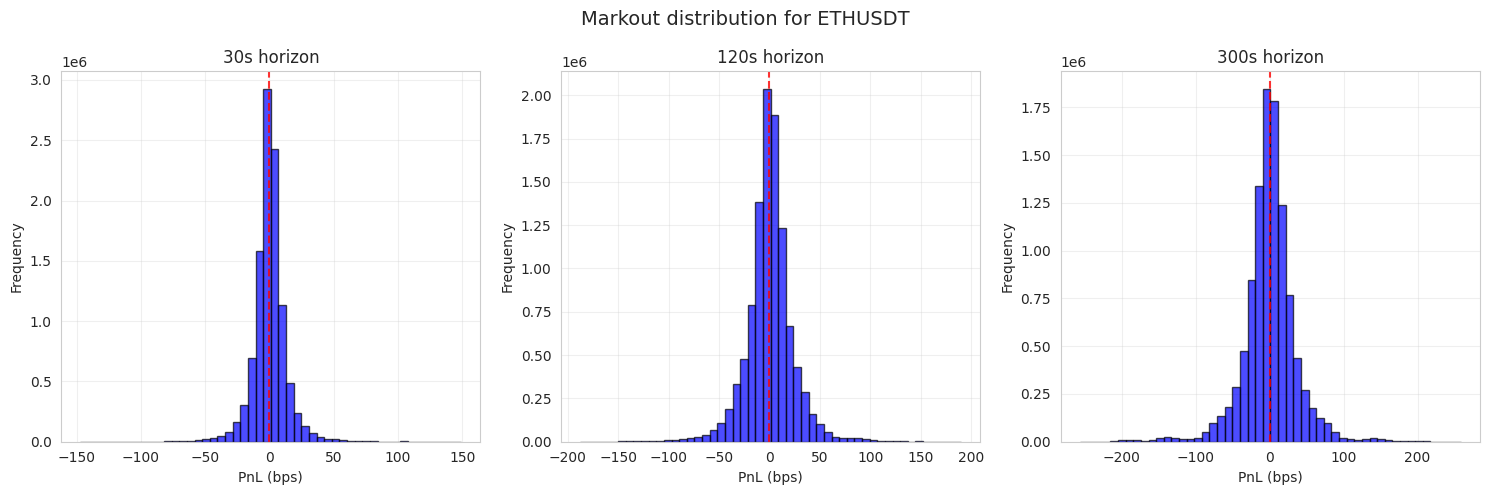

In [ ]:
def plot_markout_hist(sym: str, bins: int = 50) -> None:
    """
    Plots histograms of markout (pnl) distribution for three horizons.
    """
    if sym not in data:
        raise ValueError(f"Symbol {sym} not found in data")

    trades = data[sym]['bin_trades']
    bbo = data[sym]['bin_bbo']

    lazy_result = compute_markout(trades, bbo)  # contains pnl_30, pnl_120, pnl_300

    # Collect only needed columns
    df = (
        lazy_result
        .select(['pnl_30', 'pnl_120', 'pnl_300'])
        .collect()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    horizons = [
        ('pnl_30', '30s'),
        ('pnl_120', '120s'),
        ('pnl_300', '300s')
    ]

    for ax, (pnl_col, label) in zip(axes, horizons):
        # Remove nulls for this horizon
        data_col = df[pnl_col].drop_nulls().to_numpy()
        ax.hist(data_col, bins=bins, alpha=0.7, color='blue', edgecolor='black')
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
        ax.set_xlabel('PnL (bps)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{label} horizon')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Markout distribution for {sym.upper()}', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_markout_hist('btcusdt')
plot_markout_hist('ethusdt')


- Distributions appear symmetric, with no evident skew.



### Outliers



In [ ]:
def outlier_analysis(sym):
    amt = data[sym]['bin_trades'].select('amount').collect().to_numpy().flatten()
    q1 = np.percentile(amt, 25)
    q3 = np.percentile(amt, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = amt[(amt < lower) | (amt > upper)]
    print(f'{sym}: outliers by trade size: {len(outliers)} ({len(outliers)/len(amt)*100:.2f}%)')

print('\n=== Outlier analysis ===')
for sym in SYMBOLS:
    outlier_analysis(sym)



=== Outlier analysis ===
btcusdt: outliers by trade size: 1180507 (17.44%)
ethusdt: outliers by trade size: 1771575 (16.91%)


- There are quite many "outliers", so they cannot be considered real outliers; the volume distribution simply has fat tails.


### Autocorrelation



=== Stationarity and autocorrelation ===
btcusdt – ADF test for mid price:
  p-value = 0.00001 (stationary)


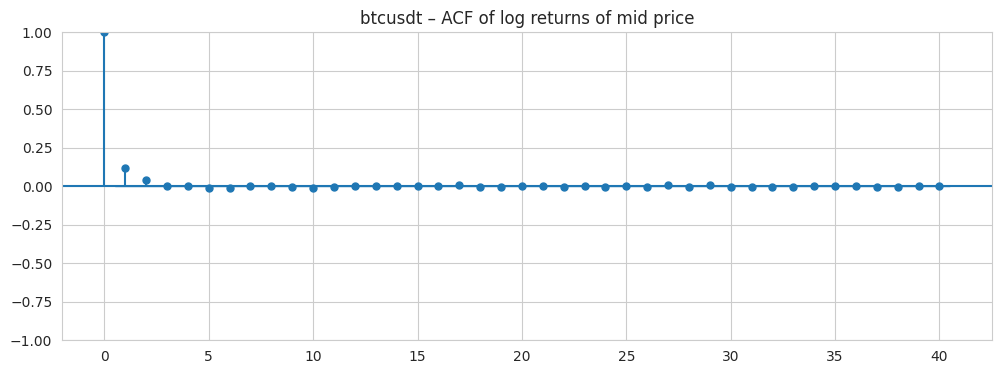

ethusdt – ADF test for mid price:
  p-value = 0.00005 (stationary)


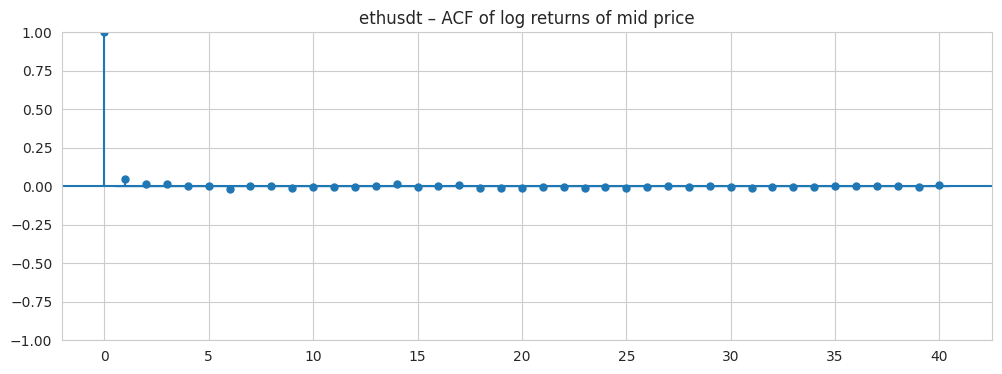

In [22]:
# Stationarity (ADF test) for mid price
def stationarity_test(sym):
    bbo = data[sym]['bin_bbo']
    # Take mid price at 1-second intervals (last value per second)
    mid_sec = bbo.with_columns(
        (pl.col('timestamp') // 1_000_000).alias('sec'),
        ((pl.col('bid_price') + pl.col('ask_price')) / 2).alias('mid')
    ).group_by('sec').agg(pl.last('mid')).collect().sort('sec')
    mid_series = mid_sec['mid'].to_numpy()
    if len(mid_series) < 10:
        print(f'{sym}: insufficient data for ADF test')
        return
    result = adfuller(mid_series, autolag='AIC')
    print(f'{sym} – ADF test for mid price:')
    print(f'  p-value = {result[1]:.5f} {"(stationary)" if result[1] < 0.05 else "(non-stationary)"}')
    # Autocorrelation for returns
    returns = np.diff(np.log(mid_series))
    plt.figure(figsize=(12,4))
    plot_acf(returns, lags=40, ax=plt.gca())
    plt.title(f'{sym} – ACF of log returns of mid price')
    plt.show()

print('\n=== Stationarity and autocorrelation ===')
for sym in SYMBOLS:
    stationarity_test(sym)


- Actually, the ADF test is not quite appropriate here because it assumes constant variance and is not suitable for series with structural breaks.



# Task 1.3 Advanced Exploration


### Orderbook imbalance




=== Orderbook imbalance ===


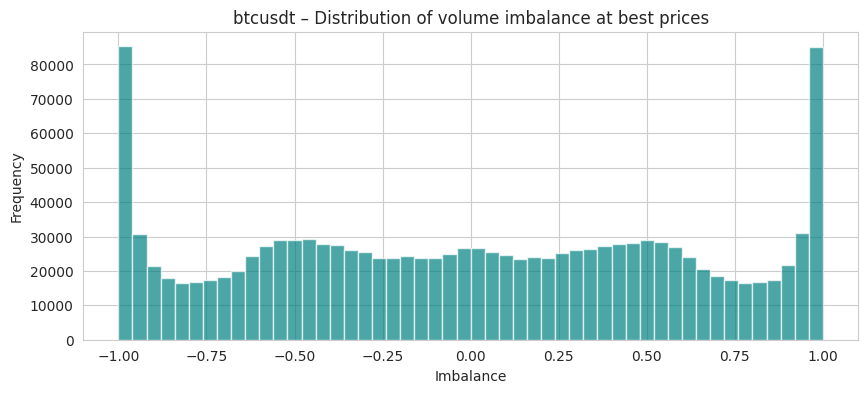

btcusdt – average imbalance: -0.0005, std: 0.6125


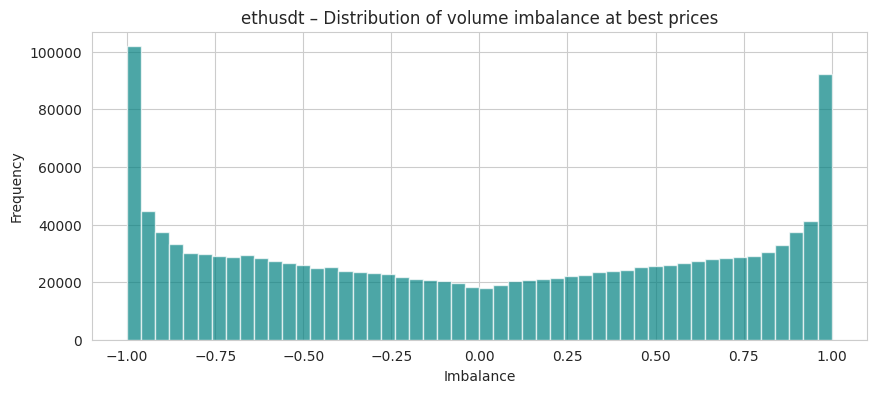

ethusdt – average imbalance: -0.0117, std: 0.6669


In [23]:
def orderbook_imbalance(sym):
    bbo = data[sym]['bin_bbo']
    # Imbalance at best bid/ask: (bid_amount - ask_amount) / (bid_amount + ask_amount)
    imb = bbo.with_columns(
        ((pl.col('bid_amount') - pl.col('ask_amount')) / (pl.col('bid_amount') + pl.col('ask_amount'))).alias('imbalance')
    ).select('imbalance').collect().to_numpy().flatten()
    plt.figure(figsize=(10,4))
    plt.hist(imb, bins=50, alpha=0.7, color='teal')
    plt.title(f'{sym} – Distribution of volume imbalance at best prices')
    plt.xlabel('Imbalance')
    plt.ylabel('Frequency')
    plt.show()
    print(f'{sym} – average imbalance: {np.mean(imb):.4f}, std: {np.std(imb):.4f}')

print('\n=== Orderbook imbalance ===')
for sym in SYMBOLS:
    orderbook_imbalance(sym)


### Volume_vs_spread



=== Volume vs spread ===


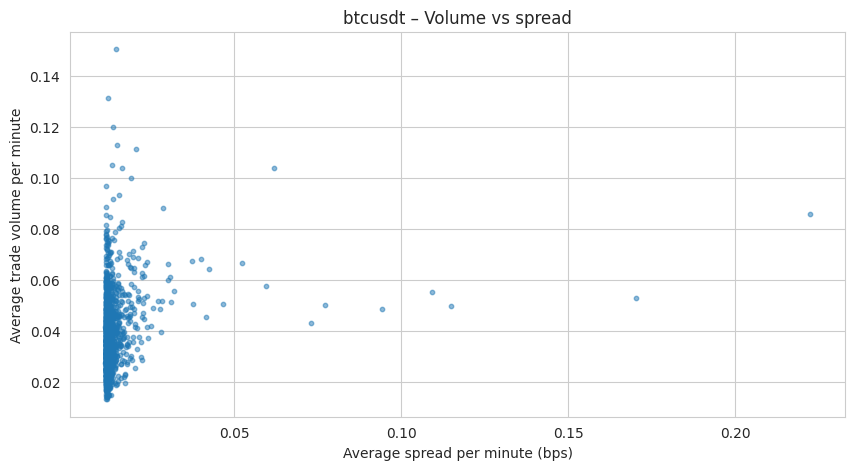

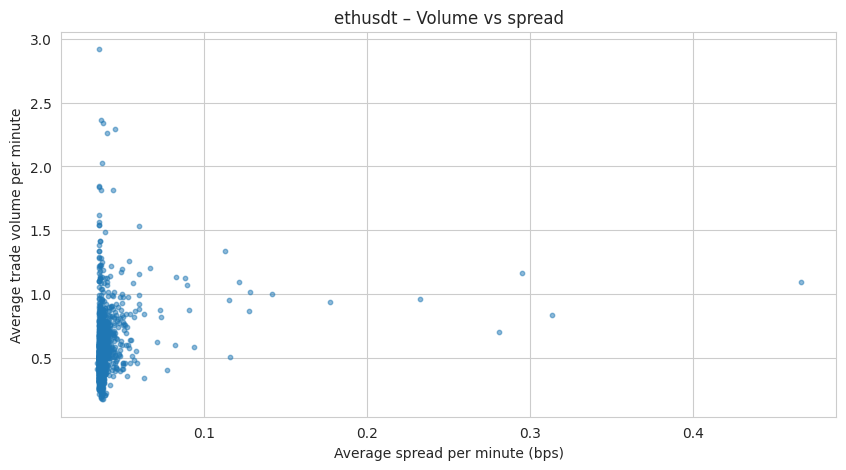

In [24]:
# Nonlinearities: trade volume vs spread
def volume_vs_spread(sym):
    trades = data[sym]['bin_trades'].select('timestamp', 'amount').collect()
    bbo = data[sym]['bin_bbo'].select('timestamp', 'bid_price', 'ask_price').collect()
    # Join by closest timestamp (asof join) – for simplicity, use cross join + filter, but that's expensive.
    # Instead, take average spread per minute and average volume per minute.
    trades_min = trades.with_columns(
        (pl.col('timestamp') // 60_000_000).alias('min')
    ).group_by('min').agg(pl.mean('amount').alias('avg_amount'))
    bbo_min = bbo.with_columns(
        (pl.col('timestamp') // 60_000_000).alias('min'),
        ((pl.col('ask_price') - pl.col('bid_price')) / pl.col('bid_price') * 10000).alias('spread_bps')
    ).group_by('min').agg(pl.mean('spread_bps').alias('avg_spread'))
    merged = trades_min.join(bbo_min, on='min', how='inner')  # already collected
    plt.figure(figsize=(10,5))
    plt.scatter(merged['avg_spread'], merged['avg_amount'], alpha=0.5, s=10)
    plt.xlabel('Average spread per minute (bps)')
    plt.ylabel('Average trade volume per minute')
    plt.title(f'{sym} – Volume vs spread')
    plt.show()

print('\n=== Volume vs spread ===')
for sym in SYMBOLS:
    volume_vs_spread(sym)


### Liquidations by side


In [25]:
def liquidation_side_analysis(sym):
    for exchange, lf in [('Binance', data[sym]['bin_liq']), ('Bybit', data[sym]['byb_liq'])]:
        side_count = lf.group_by('side').agg(pl.count().alias('count')).collect()
        buy_count = side_count.filter(pl.col('side') == 'buy')['count'].item() if (side_count['side'] == 'buy').any() else 0
        sell_count = side_count.filter(pl.col('side') == 'sell')['count'].item() if (side_count['side'] == 'sell').any() else 0
        total = buy_count + sell_count
        if total > 0:
            buy_pct = buy_count / total * 100
            sell_pct = sell_count / total * 100
            print(f'{sym} – {exchange}: buy {buy_pct:.1f}%, sell {sell_pct:.1f}%')
        else:
            print(f'{sym} – {exchange}: no data')


for sym in SYMBOLS:
    liquidation_side_analysis(sym)


btcusdt – Binance: buy 33.0%, sell 67.0%
btcusdt – Bybit: buy 14.4%, sell 85.6%
ethusdt – Binance: buy 31.0%, sell 69.0%
ethusdt – Bybit: buy 8.4%, sell 91.6%


In [26]:
def liquidation_side_analysis(sym):
    for exchange, lf in [('Binance', data[sym]['bin_liq']), ('Bybit', data[sym]['byb_liq'])]:
        side_vol = lf.group_by('side').agg(pl.sum('amount').alias('vol')).collect()
        buy_vol = side_vol.filter(pl.col('side') == 'buy')['vol'].item() if 'buy' in side_vol['side'] else 0
        sell_vol = side_vol.filter(pl.col('side') == 'sell')['vol'].item() if 'sell' in side_vol['side'] else 0
        print(f'{sym} – {exchange}: buy volume = {buy_vol:.2f}, sell volume = {sell_vol:.2f}, imbalance = {buy_vol - sell_vol:.2f}')

print('\n=== Liquidations by side ===')
for sym in SYMBOLS:
    liquidation_side_analysis(sym)



=== Liquidations by side ===
btcusdt – Binance: buy volume = 95.83, sell volume = 247.89, imbalance = -152.07
btcusdt – Bybit: buy volume = 130.10, sell volume = 951.76, imbalance = -821.66
ethusdt – Binance: buy volume = 2245.27, sell volume = 5697.09, imbalance = -3451.82
ethusdt – Bybit: buy volume = 1371.37, sell volume = 17781.64, imbalance = -16410.27


### Liquidations heatmap (spread & imbalance)


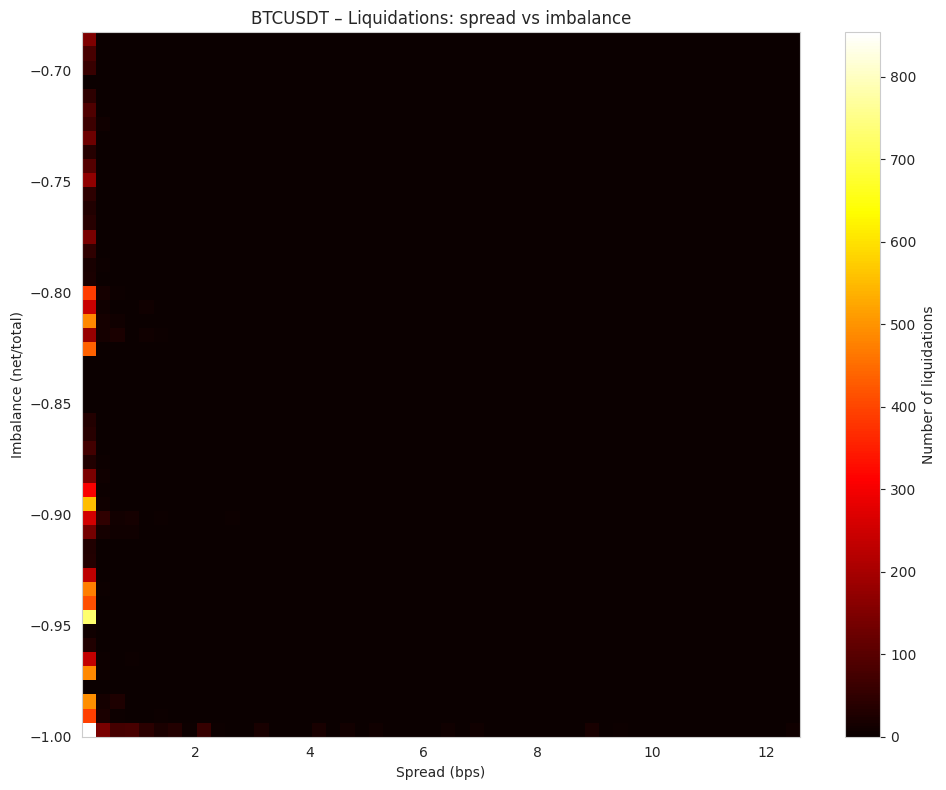

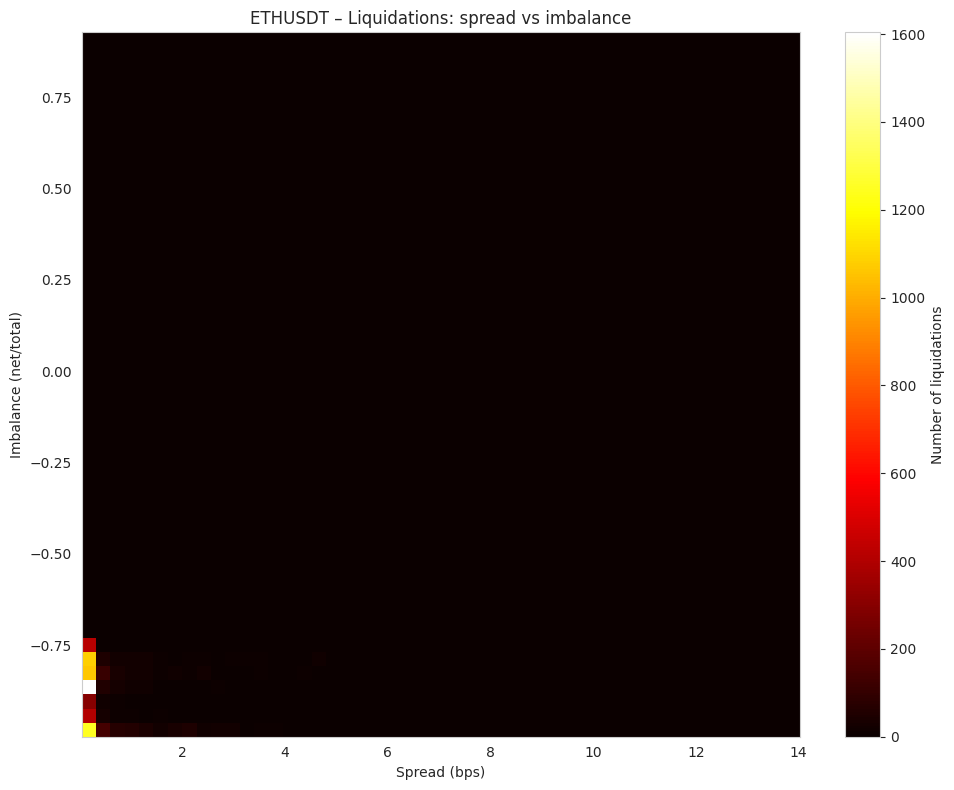

In [27]:

def plot_liquidation_heatmap(sym: str, bins_spread: int = 50, bins_imbalance: int = 50) -> None:
    """
    Plots liquidation heatmap: X-axis – spread (bps), Y-axis – cumulative imbalance (net/total).
    Uses data from Binance and Bybit (requires 'side' column).
    """
    if sym not in data:
        raise ValueError(f"Symbol {sym} not found in data")

    # 1. Collect liquidations from both exchanges (assume 'side' column exists)
    liq_bin = data[sym]['bin_liq'].select(['timestamp', 'amount', 'side']).with_columns(pl.lit('binance').alias('exchange'))
    liq_byb = data[sym]['byb_liq'].select(['timestamp', 'amount', 'side']).with_columns(pl.lit('bybit').alias('exchange'))
    liq_all = pl.concat([liq_bin, liq_byb]).sort('timestamp').collect()

    # 2. Compute cumulative imbalance
    liq_all = liq_all.with_columns(
        pl.when(pl.col('side') == 'buy').then(1).otherwise(-1).alias('sign')
    ).with_columns(
        (pl.col('sign') * pl.col('amount')).cum_sum().alias('cum_net'),
        pl.col('amount').cum_sum().alias('cum_total')
    ).with_columns(
        (pl.col('cum_net') / (pl.col('cum_total') + 1e-9)).alias('imbalance')
    )

    # 3. Prepare BBO – spread in bps
    bbo = data[sym]['bin_bbo']
    bbo = bbo.with_columns(
        ((pl.col('ask_price') - pl.col('bid_price')) / ((pl.col('bid_price') + pl.col('ask_price')) / 2) * 10000)
        .alias('spread_bps')
    ).select(['timestamp', 'spread_bps']).sort('timestamp').collect()

    # 4. For each liquidation, pull the closest spread (backward)
    liq_with_spread = liq_all.join_asof(
        bbo,
        left_on='timestamp',
        right_on='timestamp',
        strategy='backward'
    ).drop_nulls(subset=['spread_bps', 'imbalance'])

    if liq_with_spread.height == 0:
        print(f'No liquidations with available spread and imbalance for {sym}')
        return

    # 5. Extract data for heatmap
    spreads = liq_with_spread['spread_bps'].to_numpy()
    imbalances = liq_with_spread['imbalance'].to_numpy()

    # 6. Plot 2D histogram
    fig, ax = plt.subplots(figsize=(10, 8))
    h = ax.hist2d(
        spreads, imbalances,
        bins=[bins_spread, bins_imbalance],
        cmap='hot',
        density=False
    )
    ax.set_xlabel('Spread (bps)')
    ax.set_ylabel('Imbalance (net/total)')
    ax.set_title(f'{sym.upper()} – Liquidations: spread vs imbalance')
    plt.colorbar(h[3], ax=ax, label='Number of liquidations')
    plt.tight_layout()
    plt.show()

for sym in SYMBOLS:
    plot_liquidation_heatmap(sym)


- Liquidations occur at low spread and low imbalance (<0.7)


### Basic Cross-exchange signals



In [28]:
def cross_exchange_liq_price_diff(sym):
    bin_prices = data[sym]['bin_liq'].select('price').collect().to_numpy().flatten()
    byb_prices = data[sym]['byb_liq'].select('price').collect().to_numpy().flatten()
    if len(bin_prices) == 0 or len(byb_prices) == 0:
        print(f'{sym}: insufficient data for liquidation price comparison')
        return
    # Compute average prices
    mean_bin = np.mean(bin_prices)
    mean_byb = np.mean(byb_prices)
    diff_pct = (mean_bin - mean_byb) / mean_byb * 100
    print(f'{sym}: average liquidation price Binance = {mean_bin:.2f}, Bybit = {mean_byb:.2f}, difference = {diff_pct:.3f}%')

print('\n=== Liquidation price comparison (arbitrage proxy) ===')
for sym in SYMBOLS:
    cross_exchange_liq_price_diff(sym)



=== Liquidation price comparison (arbitrage proxy) ===
btcusdt: average liquidation price Binance = 86120.96, Bybit = 86316.13, difference = -0.226%
ethusdt: average liquidation price Binance = 2810.58, Bybit = 2820.58, difference = -0.355%


- Given that liquidations on exchanges occur at roughly the same time, the difference in average liquidation prices may indicate arbitrage opportunities.


### Volatility



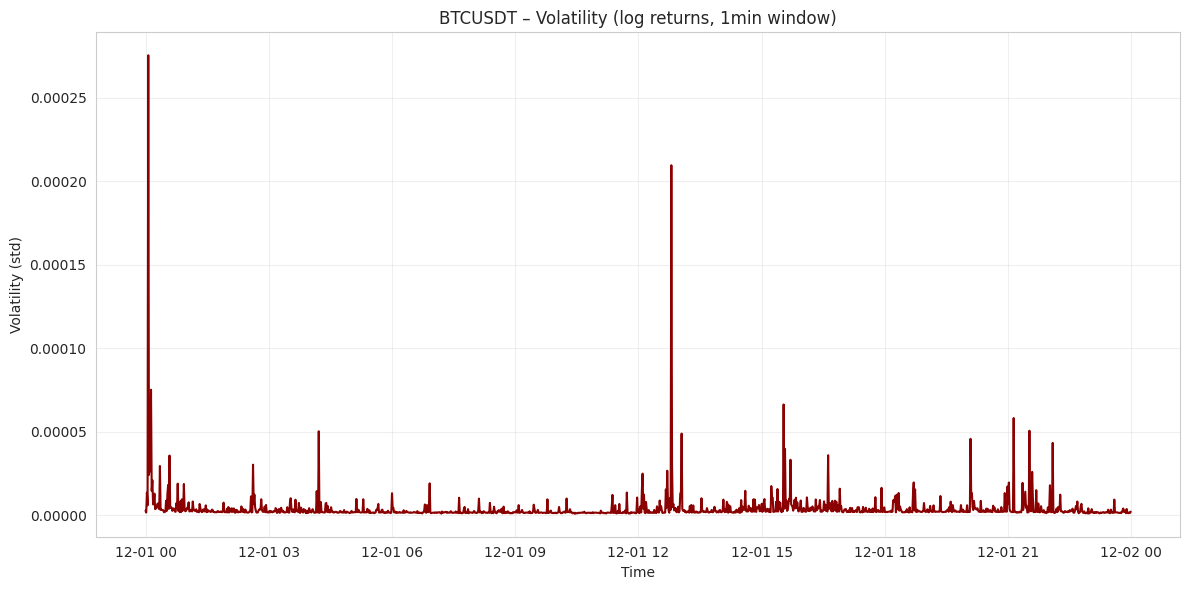

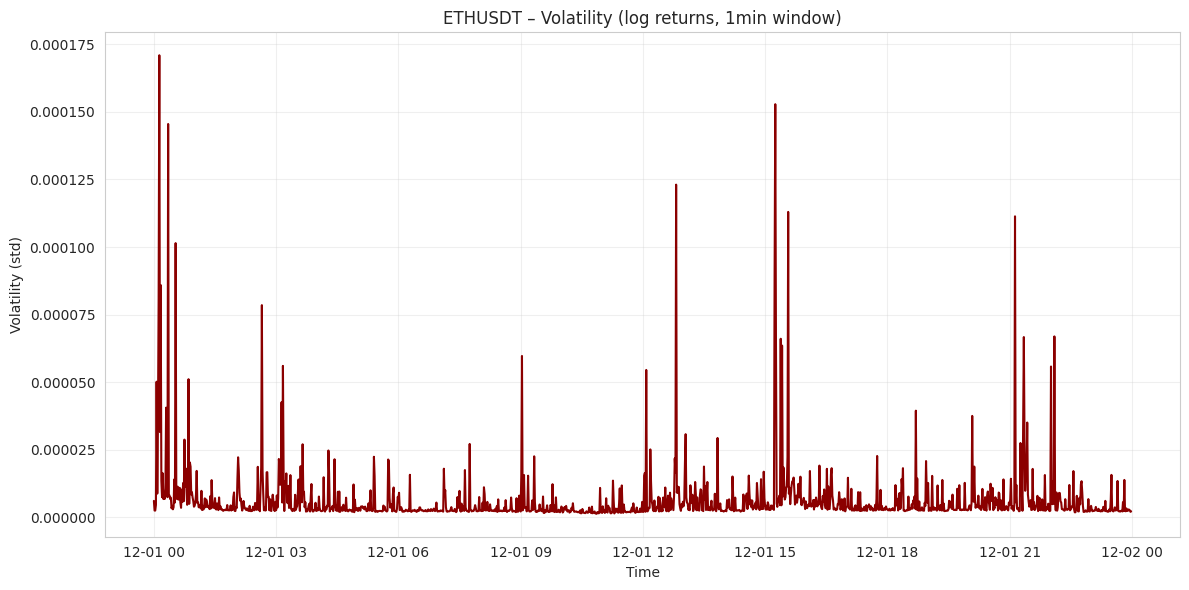

In [29]:
def plot_volatility_time(sym: str, window_minutes: int = 1) -> None:
    """
    Plots price volatility (std of log returns) over time for symbol sym.
    Aggregation interval is given in minutes.
    """
    if sym not in data:
        raise ValueError(f"Symbol {sym} not found in data")

    # Take timestamp and price, sort by time
    df = (
        data[sym]['bin_trades']
        .select(['timestamp', 'price'])
        .sort('timestamp')
        .collect()
    )

    # Assuming timestamp is in microseconds (as in compute_markout)
    df = df.with_columns(
        pl.col('timestamp').cast(pl.Datetime(time_unit='us')).alias('time')
    )

    # Log returns
    df = df.with_columns(
        (pl.col('price').log() - pl.col('price').log().shift(1)).alias('log_return')
    )

    # Group by time intervals
    vol_df = df.group_by_dynamic(
        index_column='time',
        every=f'{window_minutes}m',   # grouping interval
        period=f'{window_minutes}m',  # window length (same as every)
    ).agg(
        pl.col('log_return').std().alias('volatility')
    ).drop_nulls()

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(vol_df['time'], vol_df['volatility'], linewidth=1.5, color='darkred')
    plt.title(f'{sym.upper()} – Volatility (log returns, {window_minutes}min window)')
    plt.xlabel('Time')
    plt.ylabel('Volatility (std)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot for all symbols in SYMBOLS
for sym in SYMBOLS:
    plot_volatility_time(sym)
    # For a different window (e.g., 5 minutes):
    # plot_volatility_time(sym, window_minutes=5)


- Volatility is clearly not constant, can be used to identify market regimes.



# Executive Summary

### 1. Data quality and event frequency
- Data is clean: no missing values, duplicates exist but are most likely real partial fills of large market orders.
- Timestamp is monotonic, event order is correct.
- Frequency: trades and BBO occur at a density > 100 events/sec, liquidations are about two orders of magnitude less frequent (~1–2 per minute). This means liquidations are a rare but potentially strong signal.

### 2. Distributions and intraday patterns
- Trade sizes and liquidation volumes have fat tails (log-normal). For Bybit liquidations the tail is thicker than for Binance, indicating larger forced closures on Bybit.
- Clear hourly peaks: maximum activity occurs during the overlap of Asian, European and American sessions (UTC 8–16). Time of day can be a useful feature for anomaly detection (e.g., a spike in liquidations during illiquid hours).

### 3. Cross-exchange comparison
- Bybit surpasses Binance in both frequency and total liquidation volume for both instruments. This is important because, given cross-exchange latency (200 ms), Bybit liquidations may serve as a **leading indicator** for Binance.

### 4. Markout (maker PnL)
- The average markout of a strategy that enters every trade is negative for BTCUSDT at all horizons (30, 120, 300 s), while for ETHUSDT it is positive.
The positivity for ETHUSDT is likely because only one day was analysed; with a longer horizon it is expected to turn negative.

- A non-linear relationship is noticeable: for BTCUSDT, trades with large volume (notional > 10k) have a higher chance of positive markout, possibly due to larger informational content of large trades.

- For the cumulative markout over time (for a strategy that always trades), there are huge jumps over very short periods. This means that even if the strategy performs well most of the time, these jumps can eventually wipe out profits, so the focus should be on capturing these jumps rather than on average performance.

### 5. Market microstructure
- **Spread** is mostly narrow (mean ~0.04 bps), but widenings to several tens of bps occur, especially during high volatility.
- **Volume imbalance** at best prices (bid/ask) has a fairly uniform distribution with peaks at -1 and 1.
- Correlation between trade volume and spread is rather weak.

### 6. Liquidations and their interplay
- Side asymmetry: on both exchanges, sell liquidation volume significantly exceeds buy volume, reflecting a bearish trend during the analysed period.
- The heatmap shows that liquidations concentrate at **low spread (<1 bps) and low cumulative imbalance (<0.7)**. This indicates that liquidations occur in a calm market without order book skew, which seems counterintuitive — probably because large liquidations are executed via market orders and quickly shift the order book, bringing imbalance back to zero.

### 7. Autocorrelation and stationarity
- Log returns are stationary, but the ACF shows weak significant autocorrelation at small lags, indicating microstructure noise and potential predictability at ultra-short horizons.

### 8. Main limitations of the analysis
- The analysis was performed on **one day of data** due to memory constraints. This does not allow evaluation of seasonality (day-of-week, monthly effects) and stability of patterns over time.
- Liquidations are rare, so statistically robust conclusions require a longer period (at least several weeks).
